# Inspect UMM Tokenizer Codebook Visualization
19AUG2024 @hanoihantrakul
This notebook helps you inspect the codebook of a trained tokenizer. I was using it mainly to plot TSNE and UMAP distributions and figure out how many of the codes were being used for vocals, speech and instrumental music. 

In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
import torch
import torchaudio
import IPython.display as ipd
assert torch.cuda.is_available()
import sys
import os
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [23]:
os.chdir('/opt/tiger/samantha')

In [24]:
from recipes.umm.models.dualumm_vector_quantizers import get_vq_codebook_distances
def get_codebook_magnitudes(codebook):
    return codebook.norm(p=2,dim=1)

# Define Models

In [25]:
from recipes.umm.requires.model_initializer import (init_stage3_conv1d, init_stage3, init_stage2, init_convumm_gan)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_model_convumm_gan(ckpt_path, cache_dir):
    print(f"Downloading {ckpt_path}")
    DUMMY_RANK = 0
    token_model = init_convumm_gan(ckpt_path, DUMMY_RANK, cache_dir)[
        "Stage3"
    ].eval()
    return token_model

def load_model_convumm_conv1D(ckpt_path, cache_dir):
    print(f"Downloading {ckpt_path}")
    DUMMY_RANK = 0
    token_model = init_stage3_conv1d(ckpt_path, DUMMY_RANK, cache_dir)[
        "Stage3Conv1D"
    ].eval()
    return token_model

def load_model_conformer(ckpt_path, cache_dir):
    print(f"Downloading {ckpt_path}")
    DUMMY_RANK = 0
    token_model = init_stage3(ckpt_path, DUMMY_RANK, cache_dir)[
        "Stage3"
    ].eval()
    return token_model

def load_model_conformer_stage2(ckpt_path, cache_dir):
    print(f"Downloading {ckpt_path}")
    DUMMY_RANK = 0
    token_model = init_stage2(ckpt_path, DUMMY_RANK, cache_dir)[
        "Stage2"
    ].eval()
    return token_model

def load_model_convumm_pitch(ckpt_path, cache_dir):
    print(f"Downloading {ckpt_path}")
    DUMMY_RANK = 0
    token_model = init_stage3_conv1d(ckpt_path, DUMMY_RANK, cache_dir)[
        "Stage3Conv1D"
    ].eval()
    return token_model 

MODELS_DICT = {
    # GROUP A
    # @hanoihantrakul: 2JUN2024 This is the latest ConvUMM-GAN trained on 2255 2375. These ones incorrectly used LAS loss and are depracted in master branch.
    "convumm_gan_2255_2375": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/convumm_gan_master/convumm_gan_719M_2255_2375_vocals_bert-base-multilingual-uncased_EMAEntropy32768x32/checkpoints/step=0590000.ckpt",
    "convumm_gan_2255_2375_step100k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/convumm_gan_master/convumm_gan_719M_2255_2375_vocals_bert-base-multilingual-uncased_EMAEntropy32768x32/checkpoints/step=0100000.ckpt",
    "convumm_gan_2255_2375_step10k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/convumm_gan_master/convumm_gan_719M_2255_2375_vocals_bert-base-multilingual-uncased_EMAEntropy32768x32/checkpoints/step=0010000.ckpt",
    
    # GROUP B
    # @hanoihantrakul: 22APR2024 This is the latest Direct Stage3 ConvUMM trained on 2255 2375
    "convumm_direct_stage3_2255_2375": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/umm_conv_mixedZHEN/umm_stage3_conv1D_v2_2250mixedZHEN_2375Speech_direct_stage3_optim_mem_EMAVQ32768x32/checkpoints/step=0310000.ckpt",
    "convumm_direct_stage3_2255_2375_step100k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/umm_conv_mixedZHEN/umm_stage3_conv1D_v2_2250mixedZHEN_2375Speech_direct_stage3_optim_mem_EMAVQ32768x32/checkpoints/step=0100000.ckpt",
    "convumm_direct_stage3_2255_2375_step10k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/umm_conv_mixedZHEN/umm_stage3_conv1D_v2_2250mixedZHEN_2375Speech_direct_stage3_optim_mem_EMAVQ32768x32/checkpoints/step=0010000.ckpt",
    # @hanoihantrakul: 26APR2024 This is the latest ConformerUMM trained on 2255 2375
    "conformerumm_2255_2375": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/umm_conformer_2255mixedZHEN_2375Speech/umm_stage3_2255mixedZHEN_2375Speech_optim_mem_bert-base-multilingual-uncased_None32768x32/checkpoints/step=0180000.ckpt",
    "conformerumm_2255_2375_step10k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/umm_conformer_2255mixedZHEN_2375Speech/umm_stage3_2255mixedZHEN_2375Speech_optim_mem_bert-base-multilingual-uncased_None32768x32/checkpoints/step=0010000.ckpt",
    
    # Group C
    # @hanoihantrakul: OCT2023 Legacy ConformerUMM that was reference baseline for QQ L2S ZH. Remember though that his was trained with x4 instances.
    "legacy_conformerumm_l2s_zh": "hdfs://haruna/home/byte_speech_sv/zongyu.yin/logs/umm/umm_stage3_zh_dw1-1-0_wordpiece_vq32768x16-layer12/checkpoints/step=070000.ckpt",
    "legacy_conformerumm_l2s_zh_step10k": "hdfs://haruna/home/byte_speech_sv/zongyu.yin/logs/umm/umm_stage3_zh_dw1-1-0_wordpiece_vq32768x16-layer12/checkpoints/step=010000.ckpt",
    # @hanoihantrakul: 3JUL2024 I never trained this model, so I can only guess this was the Stage2 model used to train the Stage3 model.
    "legacy_conformerumm_l2s_zh_stage2": "hdfs://haruna/home/byte_speech_sv/zongyu.yin/logs/umm/umm_stage2_zh_dw1-1-0_wordpiece/checkpoints/step=040000.ckpt",
    # @hanoihantrakul: OCT2023 Legacy ConformerUMM that was reference baseline for QQ L2S ZH
    "legacy_conformerumm_svs": "hdfs:///home/byte_speech_sv/zongyu.yin/logs/umm_mix/umm_stage3_preclipped_bert-base-multilingual-uncased_None32768x32/checkpoints/step=0330000.ckpt",
    "legacy_conformerumm_svs_step100k": "hdfs:///home/byte_speech_sv/zongyu.yin/logs/umm_mix/umm_stage3_preclipped_bert-base-multilingual-uncased_None32768x32/checkpoints/step=0100000.ckpt",
    "legacy_conformerumm_svs_step10k": "hdfs:///home/byte_speech_sv/zongyu.yin/logs/umm_mix/umm_stage3_preclipped_bert-base-multilingual-uncased_None32768x32/checkpoints/step=0010000.ckpt",
    
    # Group D
    # @hanoihantrakul: 2JUNE2024 Supervised Pitch Loss (SPL)
    "convumm_spl": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/umm_conv_pitch_losses/umm_direct_stage3_conv1d_2255_2375_supervised_pitch_loss_EMAVQ32768x32/checkpoints/step=0500000.ckpt",
    # @hanoihantrakul: 2JUNE2024 Perceptual Pitch Loss (PPL)
    "convumm_ppl": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/umm_conv_pitch_losses/umm_direct_stage3_conv1d_2255_2375_perceptual_pitch_loss_EMAVQ32768x32/checkpoints/step=0450000.ckpt",
    # @hanoihantrakul: 2JUNE2024 Supervised + Perceptual Pitch Loss (SPL+PPL)
    "convumm_spl_ppl": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/umm_conv_pitch_losses/umm_direct_stage3_conv1d_2255_2375_supervised_and_perceptual_pitch_loss_EMAVQ32768x32/checkpoints/step=0470000.ckpt",
    "convumm_spl_ppl_step100k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/umm_conv_pitch_losses/umm_direct_stage3_conv1d_2255_2375_supervised_and_perceptual_pitch_loss_EMAVQ32768x32/checkpoints/step=0100000.ckpt",
    "convumm_spl_ppl_step10k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/umm_conv_pitch_losses/umm_direct_stage3_conv1d_2255_2375_supervised_and_perceptual_pitch_loss_EMAVQ32768x32/checkpoints/step=0010000.ckpt",
    
    # Group E
    # @hanoihantrakul: 1JUL2024 ConvUMM-GAN CTC 
    "convumm_gan_ctc1": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/convumm_gan_master/convumm_gan_766M_2255_2375_vocals_w_loss_ctc_1/checkpoints/step=0440000.ckpt",
    "convumm_gan_ctc1_step100k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/convumm_gan_master/convumm_gan_766M_2255_2375_vocals_w_loss_ctc_1/checkpoints/step=0100000.ckpt",
    "convumm_gan_ctc1_step10k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/convumm_gan_master/convumm_gan_766M_2255_2375_vocals_w_loss_ctc_1/checkpoints/step=0010000.ckpt",
    
    
    # Group 1
    # @hanoihantrakul: 20MAY2024 This is the latest ConvUMM-GAN trained on SSTK instrumentals with better E2E performance compared to ConvUMM and ConformerUMM for instrumental pipeline.
    "convumm_gan_sstk_v9_product": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/convumm_gan_master/convumm_gan_719M_sstk_None_EMAEntropy32768x32/checkpoints/step=0700000.ckpt",
    "convumm_gan_sstk_v9_product_step10k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/convumm_gan_master/convumm_gan_719M_sstk_None_EMAEntropy32768x32/checkpoints/step=0010000.ckpt",
    "convumm_gan_sstk_v9_product_step100k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/convumm_gan_master/convumm_gan_719M_sstk_None_EMAEntropy32768x32/checkpoints/step=0100000.ckpt",
    "convumm_gan_sstk_v9_product_step400k": "hdfs://haruna/home/byte_data_seed/lf_lq/speech/user/hanoi.hantrakul/logs/convumm_gan_master/convumm_gan_719M_sstk_None_EMAEntropy32768x32/checkpoints/step=0400000.ckpt",
    "conformer_sstk_locality_issue": "hdfs://haruna/home/byte_speech_sv/zongyu.yin/logs/umm_sstk/umm_stage3_None_EMAVQ32768x32_only_sstk_wo_ctc/checkpoints/step=0600000.ckpt",
    "conformer_sstk_locality_issue_step10k": "hdfs://haruna/home/byte_speech_sv/zongyu.yin/logs/umm_sstk/umm_stage3_None_EMAVQ32768x32_only_sstk_wo_ctc/checkpoints/step=0010000.ckpt",
    "conformer_sstk_locality_issue_step100k": "hdfs://haruna/home/byte_speech_sv/zongyu.yin/logs/umm_sstk/umm_stage3_None_EMAVQ32768x32_only_sstk_wo_ctc/checkpoints/step=0100000.ckpt",
    "conformer_sstk_locality_issue_step400k": "hdfs://haruna/home/byte_speech_sv/zongyu.yin/logs/umm_sstk/umm_stage3_None_EMAVQ32768x32_only_sstk_wo_ctc/checkpoints/step=0400000.ckpt",
    # @hanoihantrakul: these are the direct stage3 models
    "convumm_sstk_direct_stage3": "hdfs://haruna/home/byte_speech_sv/hanoi.hantrakul/logs/umm_conv_sstk/umm_stage3_conv1D_v2_733Mparams_sstk_no_ctc_794_direct_stage3_EMAVQ32768x32/checkpoints/step=0110000.ckpt",
    # @hanoihantrakul: ConformerUMM_TTS_ROPE trained on SSTK
    "conformerumm_tts_rope_sstk": "hdfs:///home/byte_speech_sv/hanoi.hantrakul/logs/umm_conformer_tts_rope_sstk/umm_stage3_sstk_tts_rope_None_EMAEntropy32768x32/checkpoints/step=100000.ckpt",
    "conformerumm_tts_rope_sstk_step20k": "hdfs:///home/byte_speech_sv/hanoi.hantrakul/logs/umm_conformer_tts_rope_sstk/umm_stage3_sstk_tts_rope_None_EMAEntropy32768x32/checkpoints/step=020000.ckpt",
    "conformerumm_tts_rope_sstk_step40k": "hdfs:///home/byte_speech_sv/hanoi.hantrakul/logs/umm_conformer_tts_rope_sstk/umm_stage3_sstk_tts_rope_None_EMAEntropy32768x32/checkpoints/step=040000.ckpt",
    
    # Group F
    # @hanoihantrakul: 19AUG2024 This is the latest ConformerUMM_TTS_ROPE
    "conformerumm_tts_rope_2255_2375": "hdfs:///home/byte_speech_sv/hanoi.hantrakul/logs/umm_conformer_2255mixedZHEN_tts_rope/umm_stage3_2255mixedZHEN_2375Speech_tts_rope_bert-base-multilingual-uncased/checkpoints/step=100000.ckpt",
}

In [26]:
# Select the model key based on the dictionary above

MODEL_KEY = "conformerumm_2255_2375"
ckpt_path = MODELS_DICT[MODEL_KEY]
unique_cache_dir = "./." + MODEL_KEY

In [27]:
# Load model. Uncomment the one you want

#load_func = load_model_convumm_gan
load_func = load_model_conformer
#load_func = load_model_convumm_conv1D
#load_func = load_model_conformer_stage2

token_model = load_func(ckpt_path, unique_cache_dir)

/usr/local/lib/python3.9/dist-packages/torch/nn/utils/weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


In [28]:
#codebook = token_model.vq.embedding.weight # for convumm-gan variants
codebook = token_model.model.vq.embedding.weight # for conformerumm, convumm, convumm-pitch variants
print(codebook.shape)

torch.Size([32768, 32])


# sk-learn TSNE

In [29]:
from sklearn.manifold import TSNE
import time

In [30]:
codebook_np = codebook.cpu().detach().numpy()
print(codebook_np.shape)

(32768, 32)


In [31]:
TSNE_PERPLEXITY=30
TSNE_STEPS=3000
TSNE_DIM=2

In [32]:
time_start = time.time()
tsne = TSNE(n_components=TSNE_DIM, verbose=1, perplexity=TSNE_PERPLEXITY, n_iter=TSNE_STEPS)
tsne_codebook = tsne.fit_transform(codebook_np)
print('t-SNE done! Time elapsed: {} seconds'.format(time.time()-time_start))

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 32768 samples in 0.001s...
[t-SNE] Computed neighbors for 32768 samples in 0.492s...
[t-SNE] Computed conditional probabilities for sample 1000 / 32768
[t-SNE] Computed conditional probabilities for sample 2000 / 32768
[t-SNE] Computed conditional probabilities for sample 3000 / 32768
[t-SNE] Computed conditional probabilities for sample 4000 / 32768
[t-SNE] Computed conditional probabilities for sample 5000 / 32768
[t-SNE] Computed conditional probabilities for sample 6000 / 32768
[t-SNE] Computed conditional probabilities for sample 7000 / 32768
[t-SNE] Computed conditional probabilities for sample 8000 / 32768
[t-SNE] Computed conditional probabilities for sample 9000 / 32768
[t-SNE] Computed conditional probabilities for sample 10000 / 32768
[t-SNE] Computed conditional probabilities for sample 11000 / 32768
[t-SNE] Computed conditional probabilities for sample 12000 / 32768
[t-SNE] Computed conditional probabilities for sam

In [35]:
tsne_codebook.shape

(32768, 2)

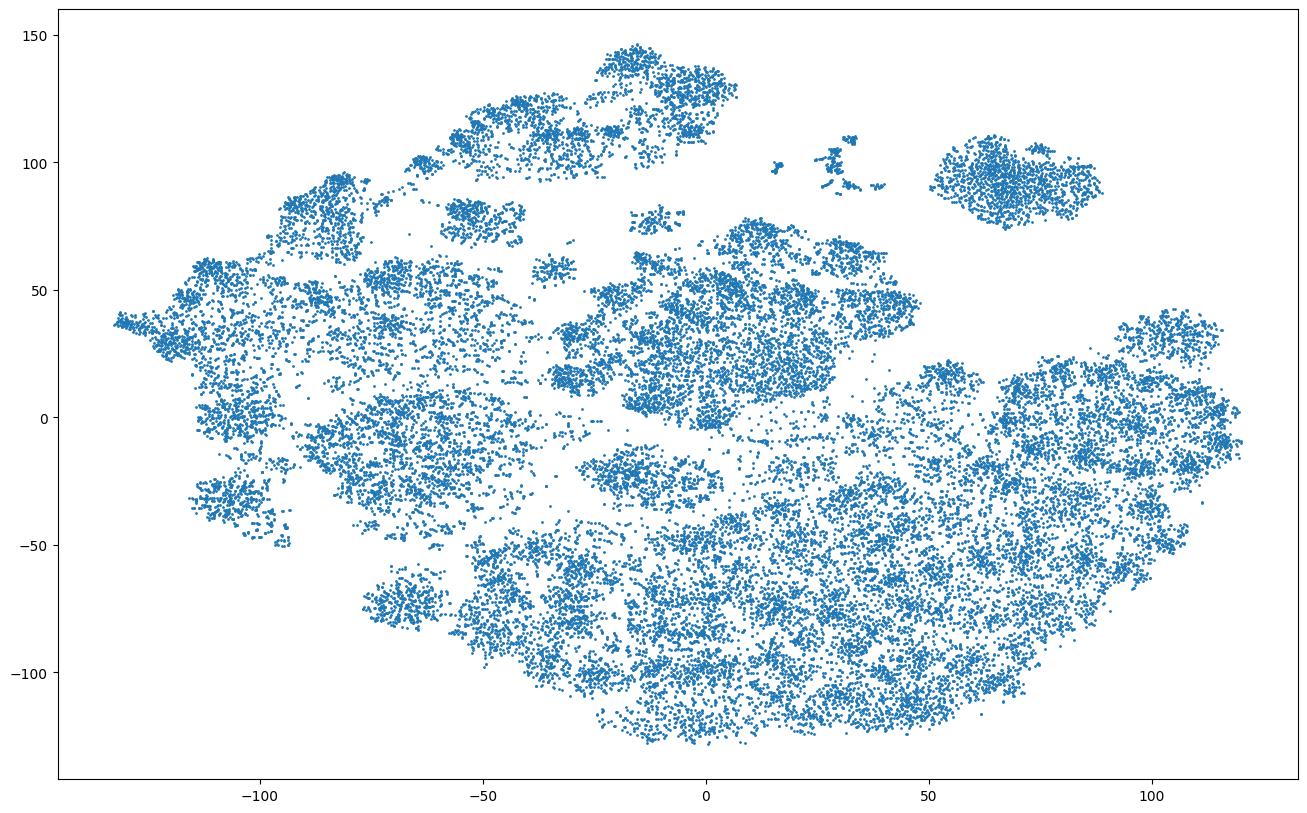

In [36]:
plt.figure(figsize=(16,10))
plt.scatter(tsne_codebook[:,0], tsne_codebook[:,1], s=1) # scatter plot of dimension 1 and dimension 2

# Load Data

In [37]:
from recipes.datasets.mcc.mix_mkii import MixDataModule
from dataclasses import dataclass
from transformers import BertTokenizer

In [38]:
#tokenizer = BertTokenizer.from_pretrained("bert-large-uncased")
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-uncased")

In [43]:
SAMPLE_RATE = 24000
HOP_LENGTH = 240
BATCH_SIZE = 20
SHUFFLE_BUFFER_SIZE = 10
MIN_DURATION = 1
MAX_DURATION = 60
TOKENIZER = None
FRAME_RATE = 25

#DATA_IDS = [794] # 2255=Vocal Music, 2375=Speech, 794=Instrumentals
DATA_WEIGHTS = [1]

NUM_ITERATIONS=5

@dataclass 
class DataLoaderConfig:
    data_ids: list
    data_weights: int
    batch_size: int
    tokenizer: None
    frame_rate: int
    min_duration: int
    max_duration: int
    hop_length: int
    num_iterations: int
    sample_rate: int
    shuffle_buffer_size: int


def get_audio_list(config):
    mdm = MixDataModule(
        data_ids=config.data_ids,
        data_weights=config.data_weights,
        batch_size=config.batch_size * config.max_duration * config.sample_rate, # means "total number of audio samples loaded into memory"
        shuffle_buffer_size=config.shuffle_buffer_size,
        sample_rate=config.sample_rate,
        min_duration=config.min_duration,
        max_duration=config.max_duration,
        frame_rate=config.frame_rate,
        tokenizer=config.tokenizer,
    )

    # There will be many printouts if loading for the first time

    dm = mdm.train_dataloader()
    dm_it = iter(dm)

    audio_list = []
    token_list = []
    for i in range(config.num_iterations):
        batch = next(dm_it)
        print(batch.keys())
        audio_list.append(batch['audio'])
        # token_list.append(batch['token'])
    
    return audio_list

In [44]:
def get_data_config(data_id):
    return DataLoaderConfig(data_ids = [data_id],
                            data_weights = [1],
                            batch_size = BATCH_SIZE,
                            tokenizer = TOKENIZER,
                            frame_rate = FRAME_RATE,
                            min_duration = MIN_DURATION,
                            max_duration = MAX_DURATION,
                            hop_length = HOP_LENGTH,
                            num_iterations = NUM_ITERATIONS,
                            sample_rate = SAMPLE_RATE,
                            shuffle_buffer_size = SHUFFLE_BUFFER_SIZE)

In [45]:
# EXPENSIVE OPERATION!
# 2255=Vocals, 2375=Speech, 794=SSTK Instrumental
#%%capture # suppress all the long printouts
time_start = time.time()
vocal_audio_list = get_audio_list(get_data_config(2255))
speech_audio_list = get_audio_list(get_data_config(2375))
inst_audio_list = get_audio_list(get_data_config(794))
print('Loading vocal, speech and instrumental dataset done! Time elapsed: {} seconds'.format(time.time()-time_start))

[Buckets] 26 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 15, 17, 19, 21, 24, 27, 30, 33, 37, 41, 46, 51, 57, 60]
[Mix] initializing...
2024-09-23 21:52:47,404 - bytedance.easycycle.bigspeech - INFO - region: Region.CN
2024-09-23 21:52:47,405 - bytedance.easycycle.bigspeech - INFO - req body: {"id": 2255, "arnold_trail_id": "33599928", "arnold_debug": "autonomous"}, headers: {'content-type': 'application/json'}
2024-09-23 21:52:48,170 - bytedance.easycycle.bigspeech - INFO - post https://bigspeech.bytedance.net/platform/api/v3/data/dataset_collection/get_dataset_collection_info_v2, status code: 200, body: {"origin":{"paths":[{"data":"hdfs://haruna/home/byte_data_seed/lf_lq/speech/data_store/BigMusic/music_Smcc_Mvocal_Gclassical-clip_N143k/data//ltype=*/part=*/*.parquet","index":"hdfs://haruna/home/byte_data_seed/lf_lq/speech/data_store/BigMusic/music_Smcc_Mvocal_Gclassical-clip_N143k/index_1//ltype=*/part=*/*.parquet","repetitions":"1"},{"data":"hdfs://haruna/home/byte_data_seed/lf_lq/speec

parse urls:   0%|          | 0/29 [00:00<?, ?it/s]

2024-09-23 21:52:48,177 - samantha.utils.hdfs_helper - INFO - Listing HDFS directory hdfs://haruna/home/byte_data_seed/lf_lq/speech/data_store/BigMusic/music_Smcc_Mvocal_Gmetal-clip_N319k/data//ltype=*/part=*
2024-09-23 21:52:48,177 - samantha.utils.hdfs_helper - INFO - Listing HDFS directory hdfs://haruna/home/byte_data_seed/lf_lq/speech/data_store/BigMusic/music_Smcc_Mvocal_Gsoundtrack-clip_N112k/data//ltype=*/part=*
2024-09-23 21:52:48,177 - samantha.utils.hdfs_helper - INFO - Listing HDFS directory hdfs://haruna/home/byte_data_seed/lf_lq/speech/data_store/BigMusic/music_Smcc_Mvocal_Gelectronic-clip_N1449k/data//ltype=*/part=*
2024-09-23 21:52:48,178 - samantha.utils.hdfs_helper - INFO - Listing HDFS directory hdfs://haruna/home/byte_data_seed/lf_lq/speech/data_store/BigMusic/music_Smcc_Mvocal_Gfolk-clip_N902k/data//ltype=*/part=*
2024-09-23 21:52:48,178 - samantha.utils.hdfs_helper - INFO - Listing HDFS directory hdfs://haruna/home/byte_data_seed/lf_lq/speech/data_store/BigMusic/mu

parse urls:   3%|▎         | 1/29 [00:04<02:17,  4.91s/it]

2024-09-23 21:52:51,810 - samantha.utils.hdfs_helper - INFO - Listing HDFS directory hdfs://haruna/home/byte_data_seed/lf_lq/speech/data_store/BigMusic/music_Smcc_Mvocal_Galternative-rock-clip_N21k/index_1//ltype=*/part=*


...

2024-09-23 21:54:57,062 - samantha.dataio.parquet.shardlists - INFO - resample data urls with mode self.replacement=False
2024-09-23 21:54:57,062 - samantha.dataio.parquet.shardlists - INFO - resample data urls with mode self.replacement=False
2024-09-23 21:54:57,063 - samantha.dataio.parquet.shardlists - INFO - resample data urls with mode self.replacement=False
2024-09-23 21:54:57,065 - samantha.dataio.parquet.shardlists - INFO - rank=0 worker=1 self.worker_seed=123356 #0 shuffle
2024-09-23 21:54:57,065 - samantha.dataio.parquet.shardlists - INFO - rank=0 worker=0 self.worker_seed=123356 #0 shuffle
2024-09-23 21:54:57,066 - samantha.dataio.parquet.shardlists - INFO - rank=0 worker=3 self.worker_seed=123356 #0 shuffle
2024-09-23 21:54:57,062 - samantha.dataio.parquet.shardlists - INFO - resample data urls with mode self.replacement=False
2024-09-23 21:54:57,103 - samantha.dataio.parquet.shardlists - INFO - rank=0 worker=2 self.worker_seed=123356 #0 shuffle


[2] Skipped 0/100 items, Messages: {}
[3] Skipped 0/100 items, Messages: {}
[2] Skipped 0/200 items, Messages: {}
[0] Skipped 0/100 items, Messages: {}
[1] Skipped 0/100 items, Messages: {}
[3] Skipped 0/200 items, Messages: {}
[2] Skipped 0/300 items, Messages: {}
[0] Skipped 0/200 items, Messages: {}
[1] Skipped 0/200 items, Messages: {}
[3] Skipped 0/300 items, Messages: {}
[2] Skipped 0/400 items, Messages: {}
[0] Skipped 0/300 items, Messages: {}
[2] Skipped 0/500 items, Messages: {}


dict_keys(['audio', 'token'])


[1] Skipped 0/300 items, Messages: {}
[3] Skipped 0/400 items, Messages: {}
[0] Skipped 0/400 items, Messages: {}


dict_keys(['audio', 'token'])
dict_keys(['audio', 'token'])
dict_keys(['audio', 'token'])
dict_keys(['audio', 'token'])
Loading vocal, speech and instrumental dataset done! Time elapsed: 137.22883558273315 seconds


In [72]:
for data_list in [vocal_audio_list, speech_audio_list, inst_audio_list]:
    print(len(data_list))
    print(data_list[0].shape)

5
torch.Size([24, 1, 1192728])
5
torch.Size([150, 1, 191759])
5
torch.Size([44, 1, 647963])


In [73]:
def get_token_ids(audio_pt, audio_tokenizer):
    token_ids = audio_tokenizer.wav2token(audio_pt)
    return token_ids

def get_token_ids_from_list(tensor_list, audio_tokenizer):
    token_ids_list = []
    for i in range(len(tensor_list)):
        audio_pt = tensor_list[i].to(device)
        token_ids_list.append(get_token_ids(audio_pt, audio_tokenizer))
    return token_ids_list

def get_flattened_token_list(token_ids_list):
    return torch.concat([x.flatten() for x in token_ids_list])

def get_unique_counts_of_token_ids(flattened_np_array_of_tokens, top_k=100, print_values=False):
    # Get the unique values and their counts
    unique_values, counts = np.unique(flattened_np_array_of_tokens, return_counts=True)
    
    count_sort_ind = np.argsort(-counts)
    
    unique_values_sorted = unique_values[count_sort_ind]
    counts_sorted = counts[count_sort_ind]

    # Print the results
    if print_values:
        cnt = 0
        for value, count in zip(unique_values_sorted, counts_sorted):
            print(f"Token ID: {value} occurs {count} times")
            cnt+=1
            if cnt > top_k:
                break
    return unique_values_sorted[0:top_k]

In [74]:
# Run from here!
# Get a list of token_ids [torch.tensor(), torch.tensor()...]
vocal_token_ids_list = get_token_ids_from_list(vocal_audio_list, token_model)
speech_token_ids_list = get_token_ids_from_list(speech_audio_list, token_model)
inst_token_ids_list = get_token_ids_from_list(inst_audio_list, token_model)

# Get a flattened torch.tensor() of token_ids
vocal_token_ids = get_flattened_token_list(vocal_token_ids_list)
speech_token_ids = get_flattened_token_list(speech_token_ids_list)
inst_token_ids = get_flattened_token_list(inst_token_ids_list)
print(vocal_token_ids.shape)
print(speech_token_ids.shape)
print(inst_token_ids.shape)

torch.Size([149608])
torch.Size([149800])
torch.Size([149232])


In [75]:
# convert torch.tensor() to numpy.array()
vocal_token_ids_np = vocal_token_ids.cpu().detach().numpy()
speech_token_ids_np = speech_token_ids.cpu().detach().numpy()
inst_token_ids_np = inst_token_ids.cpu().detach().numpy()

In [76]:
TOP_K = 2500
top_k_vocal_token_ids = get_unique_counts_of_token_ids(vocal_token_ids_np, top_k=TOP_K)
#print(top_k_vocal_token_ids)
top_k_speech_token_ids = get_unique_counts_of_token_ids(speech_token_ids_np, top_k=TOP_K)
#print(top_k_speech_token_ids)
top_k_inst_token_ids = get_unique_counts_of_token_ids(inst_token_ids_np, top_k=TOP_K)
#print(top_k_inst_token_ids)

# Index into the 2 dimensional TSNE projection of the original codebook
tsne_top_k_vocal_tokens = tsne_codebook[top_k_vocal_token_ids]
print(tsne_top_k_vocal_tokens.shape)

tsne_top_k_speech_tokens = tsne_codebook[top_k_speech_token_ids]
print(tsne_top_k_speech_tokens.shape)

tsne_top_k_inst_tokens = tsne_codebook[top_k_inst_token_ids]
print(tsne_top_k_inst_tokens.shape)

(2500, 2)
(2500, 2)
(2500, 2)


In [77]:
S_SIZE=1
ALPHA=0.3

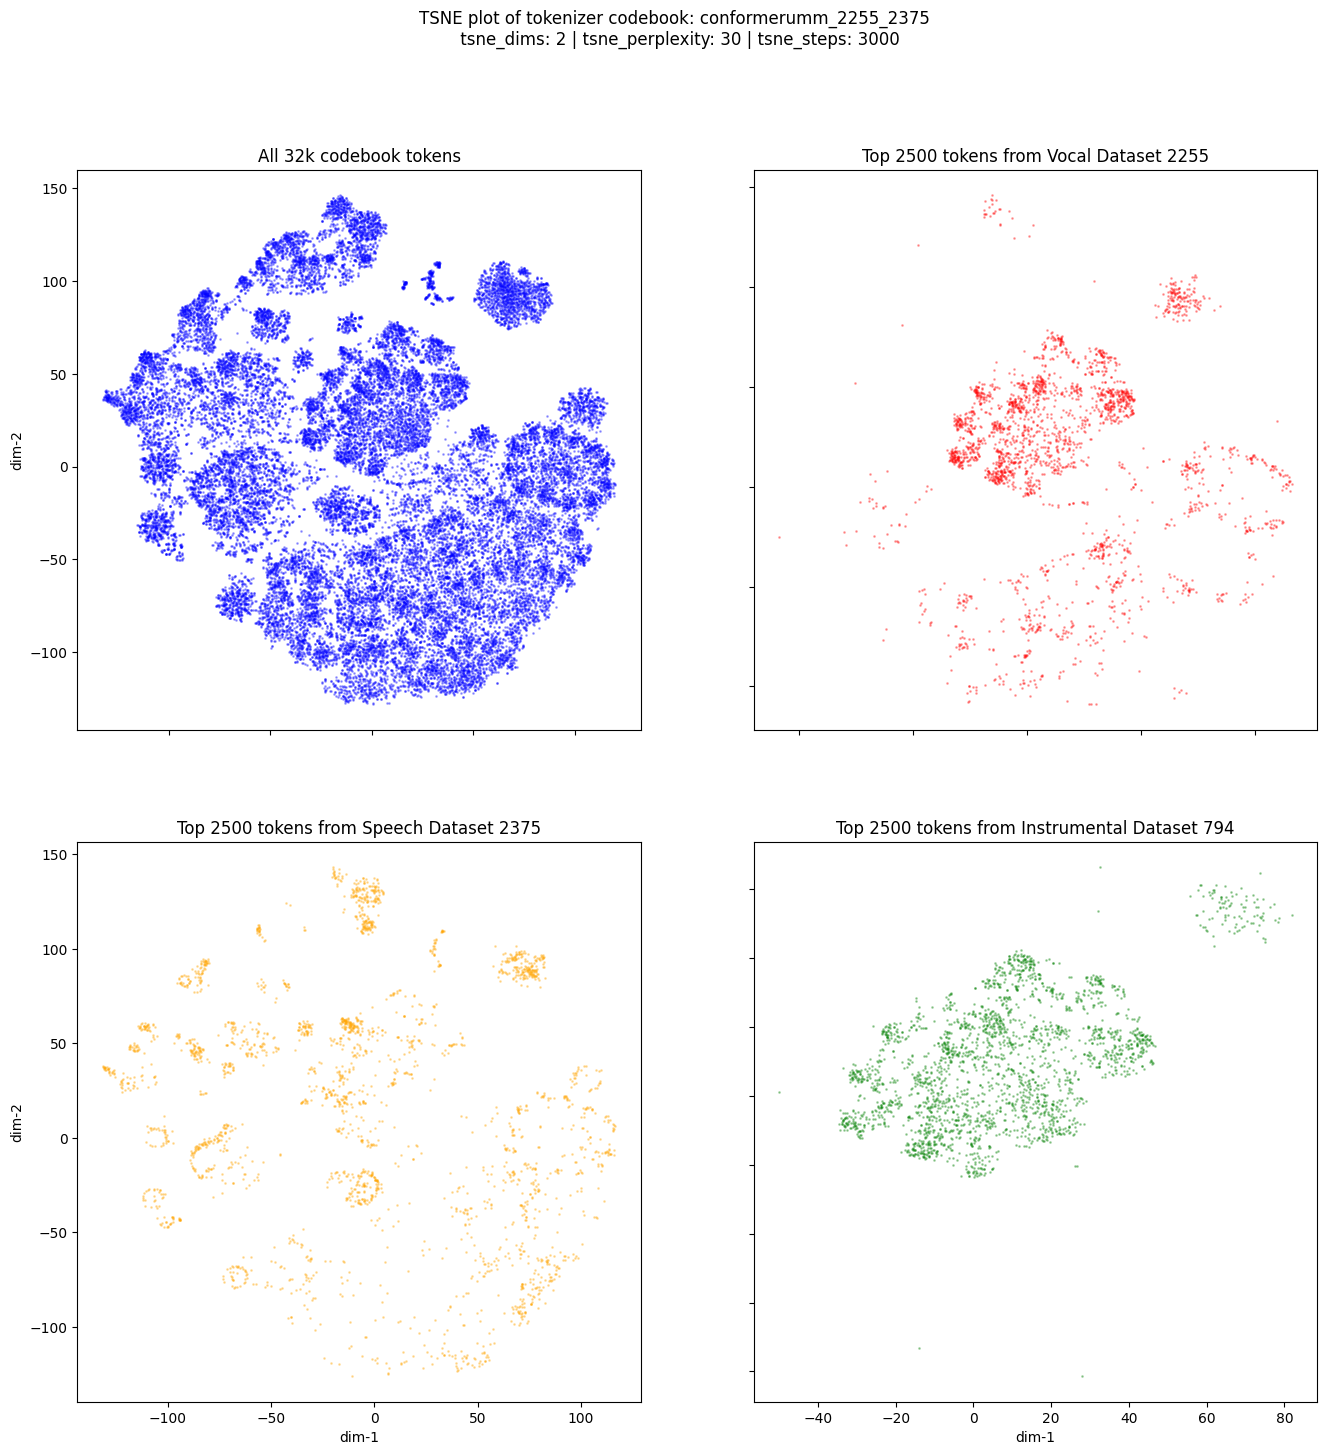

In [79]:
fig, axs = plt.subplots(2, 2, figsize=(16, 16))
plt.suptitle(f"TSNE plot of tokenizer codebook: {MODEL_KEY} \n tsne_dims: {TSNE_DIM} | tsne_perplexity: {TSNE_PERPLEXITY} | tsne_steps: {TSNE_STEPS}")

axs[0, 0].set_title('All 32k codebook tokens')
axs[0, 0].scatter(tsne_codebook[:,0], tsne_codebook[:,1], s=S_SIZE, alpha=ALPHA, color='blue') # scatter plot of dimension 1 and dimension 2

axs[0, 1].set_title(f"Top {TOP_K} tokens from Vocal Dataset 2255")
axs[0, 1].scatter(tsne_top_k_vocal_tokens[:,0], tsne_top_k_vocal_tokens[:,1], s=S_SIZE, alpha=ALPHA, color='red')

axs[1, 0].set_title(f"Top {TOP_K} tokens from Speech Dataset 2375")
axs[1, 0].scatter(tsne_top_k_speech_tokens[:,0], tsne_top_k_speech_tokens[:,1], s=S_SIZE, alpha=ALPHA, color='orange')

axs[1, 1].set_title(f"Top {TOP_K} tokens from Instrumental Dataset 794")
axs[1, 1].scatter(tsne_top_k_inst_tokens[:,0], tsne_top_k_inst_tokens[:,1], s=S_SIZE, alpha=ALPHA, color='green')

for ax in axs.flat:
    ax.set(xlabel='dim-1', ylabel='dim-2')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()

In [80]:
# Compute Top K Overlaps
def get_percent(a,b):
    return (a/b)*100

vocal_ids_set, speech_ids_set, inst_ids_set = set(top_k_vocal_token_ids.tolist()), set(top_k_speech_token_ids.tolist()), set(top_k_inst_token_ids.tolist())
vocal_vs_speech = vocal_ids_set.intersection(speech_ids_set)
vocal_vs_speech_overlap_percent = get_percent(len(vocal_vs_speech),len(vocal_ids_set))
print(len(vocal_ids_set))
print(len(speech_ids_set))
print(f"Vocal Vs Speech Overlapping Tokens Number: {len(vocal_vs_speech)}")
print(f"Vocal Vs Speech Overlapping Tokens Percentage: {vocal_vs_speech_overlap_percent:0.2f}%")

vocal_vs_inst = vocal_ids_set.intersection(inst_ids_set)
vocal_vs_inst_overlap_percent = get_percent(len(vocal_vs_inst),len(inst_ids_set))
print(len(vocal_ids_set))
print(len(inst_ids_set))
print(f"Vocal Vs Inst Overlapping Tokens Number: {len(vocal_vs_inst)}")
print(f"Vocal Vs Inst Overlapping Tokens Percentage: {vocal_vs_inst_overlap_percent:0.2f}%")

speech_vs_inst = speech_ids_set.intersection(inst_ids_set)
speech_vs_inst_overlap_percent = get_percent(len(speech_vs_inst),len(inst_ids_set))
print(len(speech_ids_set))
print(len(inst_ids_set))
print(f"Speech Vs Inst Overlapping Tokens Number: {len(speech_vs_inst)}")
print(f"Speech Vs Inst Overlapping Tokens Percentage: {speech_vs_inst_overlap_percent:0.2f}%")

2500
2500
Vocal Vs Speech Overlapping Tokens Number: 102
Vocal Vs Speech Overlapping Tokens Percentage: 4.08%
2500
2500
Vocal Vs Inst Overlapping Tokens Number: 1066
Vocal Vs Inst Overlapping Tokens Percentage: 42.64%
2500
2500
Speech Vs Inst Overlapping Tokens Number: 114
Speech Vs Inst Overlapping Tokens Percentage: 4.56%


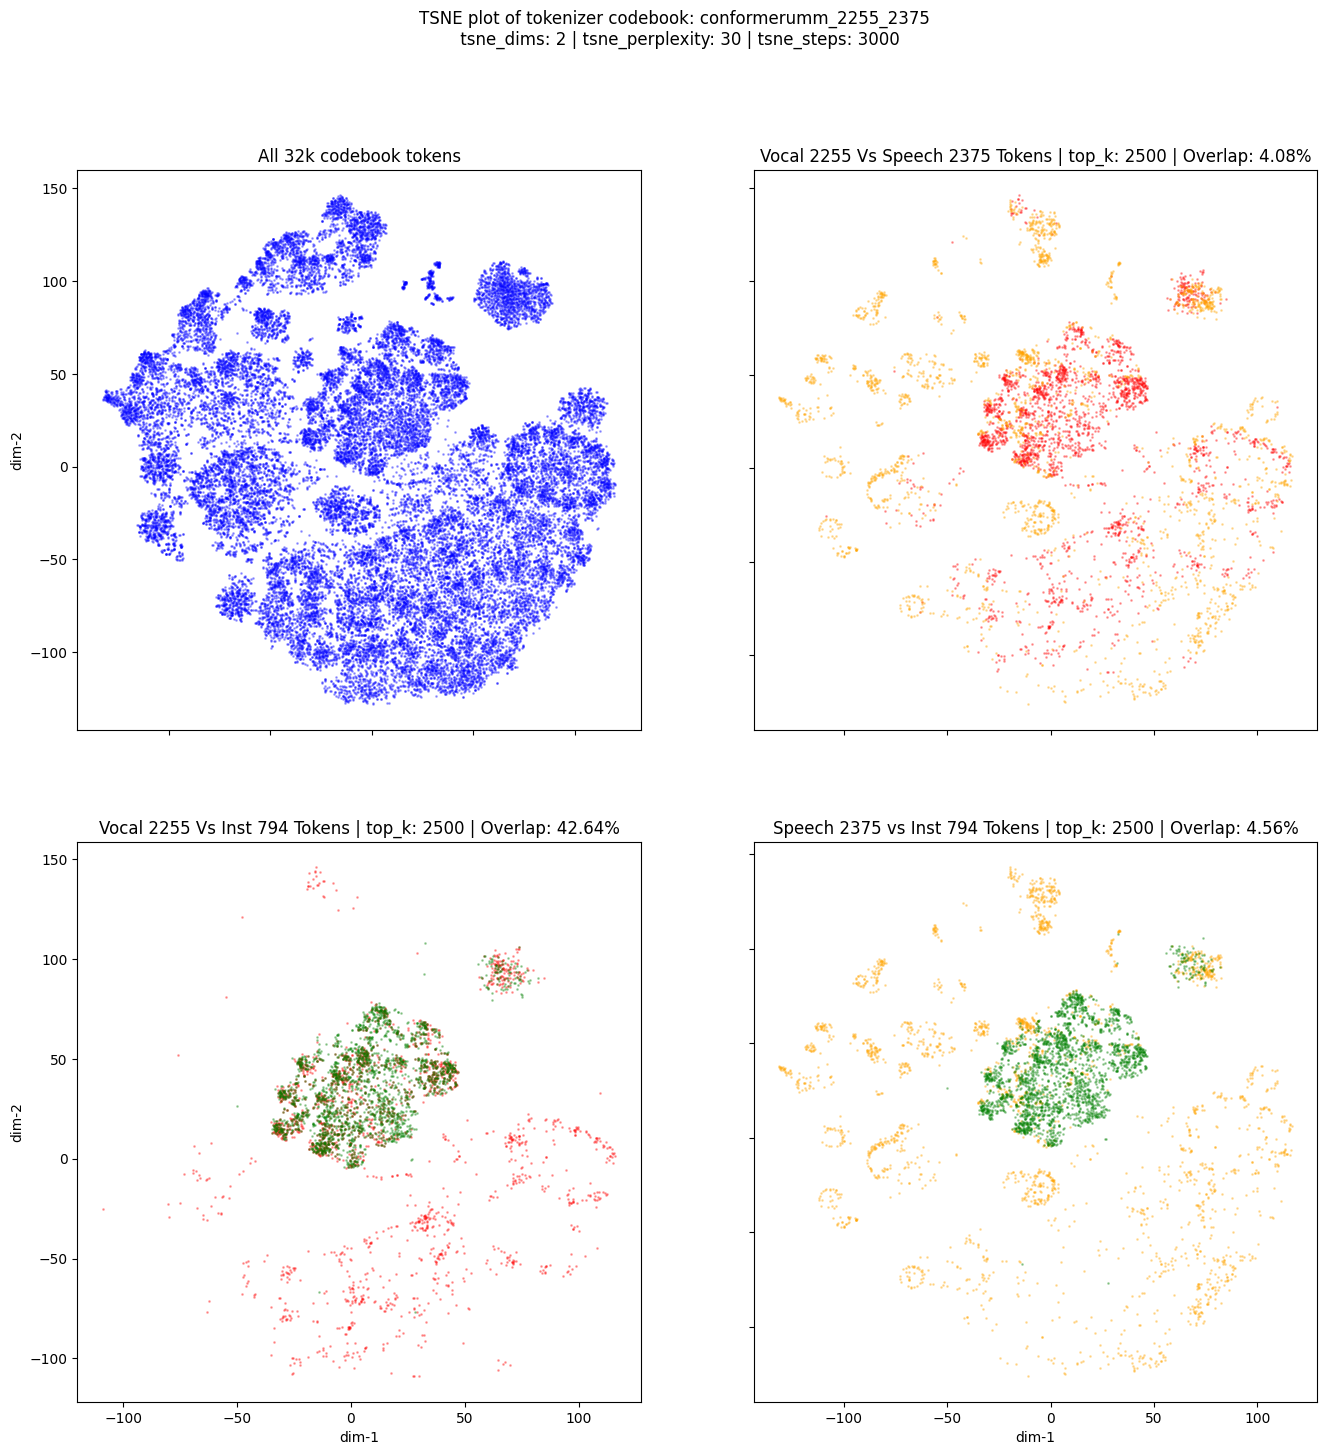

In [82]:
fig, axs = plt.subplots(2, 2, figsize=(16, 16))
plt.suptitle(f"TSNE plot of tokenizer codebook: {MODEL_KEY} \n tsne_dims: {TSNE_DIM} | tsne_perplexity: {TSNE_PERPLEXITY} | tsne_steps: {TSNE_STEPS}")

axs[0, 0].set_title('All 32k codebook tokens')
axs[0, 0].scatter(tsne_codebook[:,0], tsne_codebook[:,1], s=S_SIZE, alpha=ALPHA, color='blue') # scatter plot of dimension 1 and dimension 2

axs[0, 1].set_title(f"Vocal 2255 Vs Speech 2375 Tokens | top_k: {TOP_K} | Overlap: {vocal_vs_speech_overlap_percent:0.2f}%")
axs[0, 1].scatter(tsne_top_k_vocal_tokens[:,0], tsne_top_k_vocal_tokens[:,1], s=S_SIZE, alpha=ALPHA, color='red')
axs[0, 1].scatter(tsne_top_k_speech_tokens[:,0], tsne_top_k_speech_tokens[:,1], s=S_SIZE, alpha=ALPHA, color='orange')

axs[1, 0].set_title(f"Vocal 2255 Vs Inst 794 Tokens | top_k: {TOP_K} | Overlap: {vocal_vs_inst_overlap_percent:0.2f}%")
axs[1, 0].scatter(tsne_top_k_vocal_tokens[:,0], tsne_top_k_vocal_tokens[:,1], s=S_SIZE, alpha=ALPHA, color='red')
axs[1, 0].scatter(tsne_top_k_inst_tokens[:,0], tsne_top_k_inst_tokens[:,1], s=S_SIZE, alpha=ALPHA, color='green')

axs[1, 1].set_title(f"Speech 2375 vs Inst 794 Tokens | top_k: {TOP_K} | Overlap: {speech_vs_inst_overlap_percent:0.2f}%")
axs[1, 1].scatter(tsne_top_k_speech_tokens[:,0], tsne_top_k_speech_tokens[:,1], s=S_SIZE, alpha=ALPHA, color='orange')
axs[1, 1].scatter(tsne_top_k_inst_tokens[:,0], tsne_top_k_inst_tokens[:,1], s=S_SIZE, alpha=ALPHA, color='green')

for ax in axs.flat:
    ax.set(xlabel='dim-1', ylabel='dim-2')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()

In [83]:
tsne_vocal_tokens = tsne_codebook[vocal_token_ids_np]
print(tsne_vocal_tokens.shape)

tsne_speech_tokens = tsne_codebook[speech_token_ids_np]
print(tsne_vocal_tokens.shape)

tsne_inst_tokens = tsne_codebook[vocal_token_ids_np]
print(tsne_vocal_tokens.shape)

(149608, 2)
(149608, 2)
(149608, 2)


In [88]:
# plt.figure(figsize=(16,10))
# plt.scatter(tsne_codebook[:,0], tsne_codebook[:,1], s=1, color='blue') # scatter plot of dimension 1 and dimension 2


In [89]:
# plt.figure(figsize=(16,10))
# plt.scatter(tsne_vocal_tokens[:,0], tsne_vocal_tokens[:,1], s=1, color='red')

In [90]:
# plt.figure(figsize=(16,10))
# plt.scatter(tsne_speech_tokens[:,0], tsne_speech_tokens[:,1], s=1, color='orange')

In [91]:
# plt.figure(figsize=(16,10))
# plt.scatter(tsne_inst_tokens[:,0], tsne_inst_tokens[:,1], s=1, color='green')

# Loading Audio

In [240]:
loaded_audio_list = []
for suffix in ["Melodica","Hum","EN","TH","ZH"]:
    audio_file = f"recipes/umm/notebooks/Hanoi_{suffix}.wav"
    print(f"{audio_file}")
    waveform, sample_rate = torchaudio.load(audio_file)
    waveform = waveform[0:1, :]
    print(waveform.shape)
    waveform = torchaudio.functional.resample(waveform, orig_freq=48000, new_freq=SAMPLE_RATE)
    waveform = torchaudio.functional.lowpass_biquad(waveform, SAMPLE_RATE, 50, Q=0.707)
    print(waveform.shape)
    loaded_audio_list.append(waveform)

recipes/umm/notebooks/Hanoi_Melodica.wav
torch.Size([1, 186150])
torch.Size([1, 93075])
recipes/umm/notebooks/Hanoi_Hum.wav
torch.Size([1, 235051])
torch.Size([1, 117526])
recipes/umm/notebooks/Hanoi_EN.wav
torch.Size([1, 214989])
torch.Size([1, 107495])
recipes/umm/notebooks/Hanoi_TH.wav
torch.Size([1, 203704])
torch.Size([1, 101852])
recipes/umm/notebooks/Hanoi_ZH.wav
torch.Size([1, 187404])
torch.Size([1, 93702])


In [241]:
ipd.Audio(loaded_audio_list[0], rate=SAMPLE_RATE)

In [242]:
ipd.Audio(loaded_audio_list[1], rate=SAMPLE_RATE)

In [243]:
ipd.Audio(loaded_audio_list[2], rate=SAMPLE_RATE)

In [244]:
ipd.Audio(loaded_audio_list[3], rate=SAMPLE_RATE)

In [245]:
ipd.Audio(loaded_audio_list[4], rate=SAMPLE_RATE)

In [246]:
for i in range(5):
    loaded_audio_list[i] = loaded_audio_list[i].unsqueeze(0)

In [247]:
vocal_audio_list[0].shape

torch.Size([24, 1, 1192728])

In [248]:
loaded_audio_list[0].shape

torch.Size([1, 1, 93075])

In [249]:
loaded_audio_token_ids_list = get_token_ids_from_list(loaded_audio_list, token_model)

In [250]:
len(loaded_audio_token_ids_list)

5

In [251]:
print(loaded_audio_token_ids_list[0].shape)

torch.Size([1, 97])


In [252]:
melodica_token_ids = loaded_audio_token_ids_list[0].cpu().numpy().squeeze()
print(melodica_token_ids)

[31845 27423  6010 28620  7842  5302  5302 22997 22997 22997 22997 22997
 22997 22997 22997 22997 22997 22203 27983 22203 19324  7580  7580  7580
  7580  7580  7580  7580  7580  7580  7580  7580  7580  7580  7580  7580
  5286 22203 13188 23369 23369 23369 23369  5783  5783  4649 27827 27827
 27827  5783  5286 13649 29878 22354 22354 22354 22354 22354 22354 22354
 22354 22354 22354 22354 22354 22354 22354 22354 22354 22354 22354 22354
 10157 13526  1224  1224 27983 27983 27983 27983 27983 28620 23451 23451
 23451 23451 23451 28620 28620 23451 28620  7842 28620 28620 27279 27279
 13748]


In [253]:
hum_token_ids = loaded_audio_token_ids_list[1].cpu().numpy().squeeze()
print(hum_token_ids)

[14549 16755 19775 19775 19775 19775 19775 16950 16950 16950 16950 16950
 16950 24248 24248 24248 20622 20622 20622 20622 20622 19775 20622 20622
 19775 20622 20622 20622 20622 20622 20622 20622 20622 20622 20622 20622
 20622 20622 20622 20622 20622 20622 20622 20622 20622 20622 20622 10523
 10523 10523 22997 22997 23955 20622 20622 20622 20622 20622 20622 19775
 19775 20622 20622 20622 20622 20622 20622 20622 20622 20622 20622 20622
 20622 20622 20622 20622 20622 20622 20622 20622 20622 20622 20622 20622
 13649 13649 20622 20622 20622 20622 13649 20622 20622 13649 13649 13649
 13649 13649 13649 13649 13649 13649 13649 20622 20622 20622 20622 20622
 20622 20622 20622 20622 20622 20622 20622 20622 19775 19775 19775 19775
 24287 24202  3093]


In [254]:
en_token_ids = loaded_audio_token_ids_list[2].cpu().numpy().squeeze()
print(en_token_ids)

[   81 14090 23451 16950 16950 16950 16950 16950 16950 16950 16950 16950
 16950 16950 16950 16950 16950 20622 20622 20622 20622 13649 13649 13649
  8783  8783  5286  5286 21766 20622 20622 20622 16950 16950 20622 21766
  5286  5286 23823  2856  2856  2998  2998  2998  2998  5614  2998  2998
  2998  5614  5614  2998 21949  9711  9711  5286 13188 13188 13188 24906
 29362 29362 29362 29362 15874 24482 16830  8920 32512  5286 13649 13649
 17670 17670 17670  1224  1224  1224  1224  1224  1224  1224 24248 20622
 20622 20622 20622 20622 20622 20622 20622 20622 20622 20622 27983 27983
 20622 16950 16950 16950 16950 16950 16950 16950 16950 16950 16950 16950
 27983 23451 14744 17187]


In [255]:
th_token_ids = loaded_audio_token_ids_list[3].cpu().numpy().squeeze()
print(en_token_ids)

[   81 14090 23451 16950 16950 16950 16950 16950 16950 16950 16950 16950
 16950 16950 16950 16950 16950 20622 20622 20622 20622 13649 13649 13649
  8783  8783  5286  5286 21766 20622 20622 20622 16950 16950 20622 21766
  5286  5286 23823  2856  2856  2998  2998  2998  2998  5614  2998  2998
  2998  5614  5614  2998 21949  9711  9711  5286 13188 13188 13188 24906
 29362 29362 29362 29362 15874 24482 16830  8920 32512  5286 13649 13649
 17670 17670 17670  1224  1224  1224  1224  1224  1224  1224 24248 20622
 20622 20622 20622 20622 20622 20622 20622 20622 20622 20622 27983 27983
 20622 16950 16950 16950 16950 16950 16950 16950 16950 16950 16950 16950
 27983 23451 14744 17187]


In [256]:
zh_token_ids = loaded_audio_token_ids_list[4].cpu().numpy().squeeze()
print(zh_token_ids)

[   81 23451 23451 16950 16950 16950 16950 16950 16950 16950 16950 16950
  9477 16950 20046 16950 16950 22203 22203 22203 22203 22203 22203 13649
 21766  5286 11875 23666 23666  9209  9209 17386  5614  5614  5614 27064
  5614  5614  5614  5614  5614  5614  5614  5614  5614  4266 23823  9711
  5286  5286  5286 13649 13649 15431 15431 13649 15431 15431 24287 24287
 24287 24287 13649 13649 20622 20622 20622 20622 20622 20622 20622 20622
 20622 20622 20622 20622 20622 20622 20622 20622 20622 20622 20622 20622
 20622 20622 20622 24287 16950 16950 16950 16950 16950 24287 24287   167
  8087  3093]


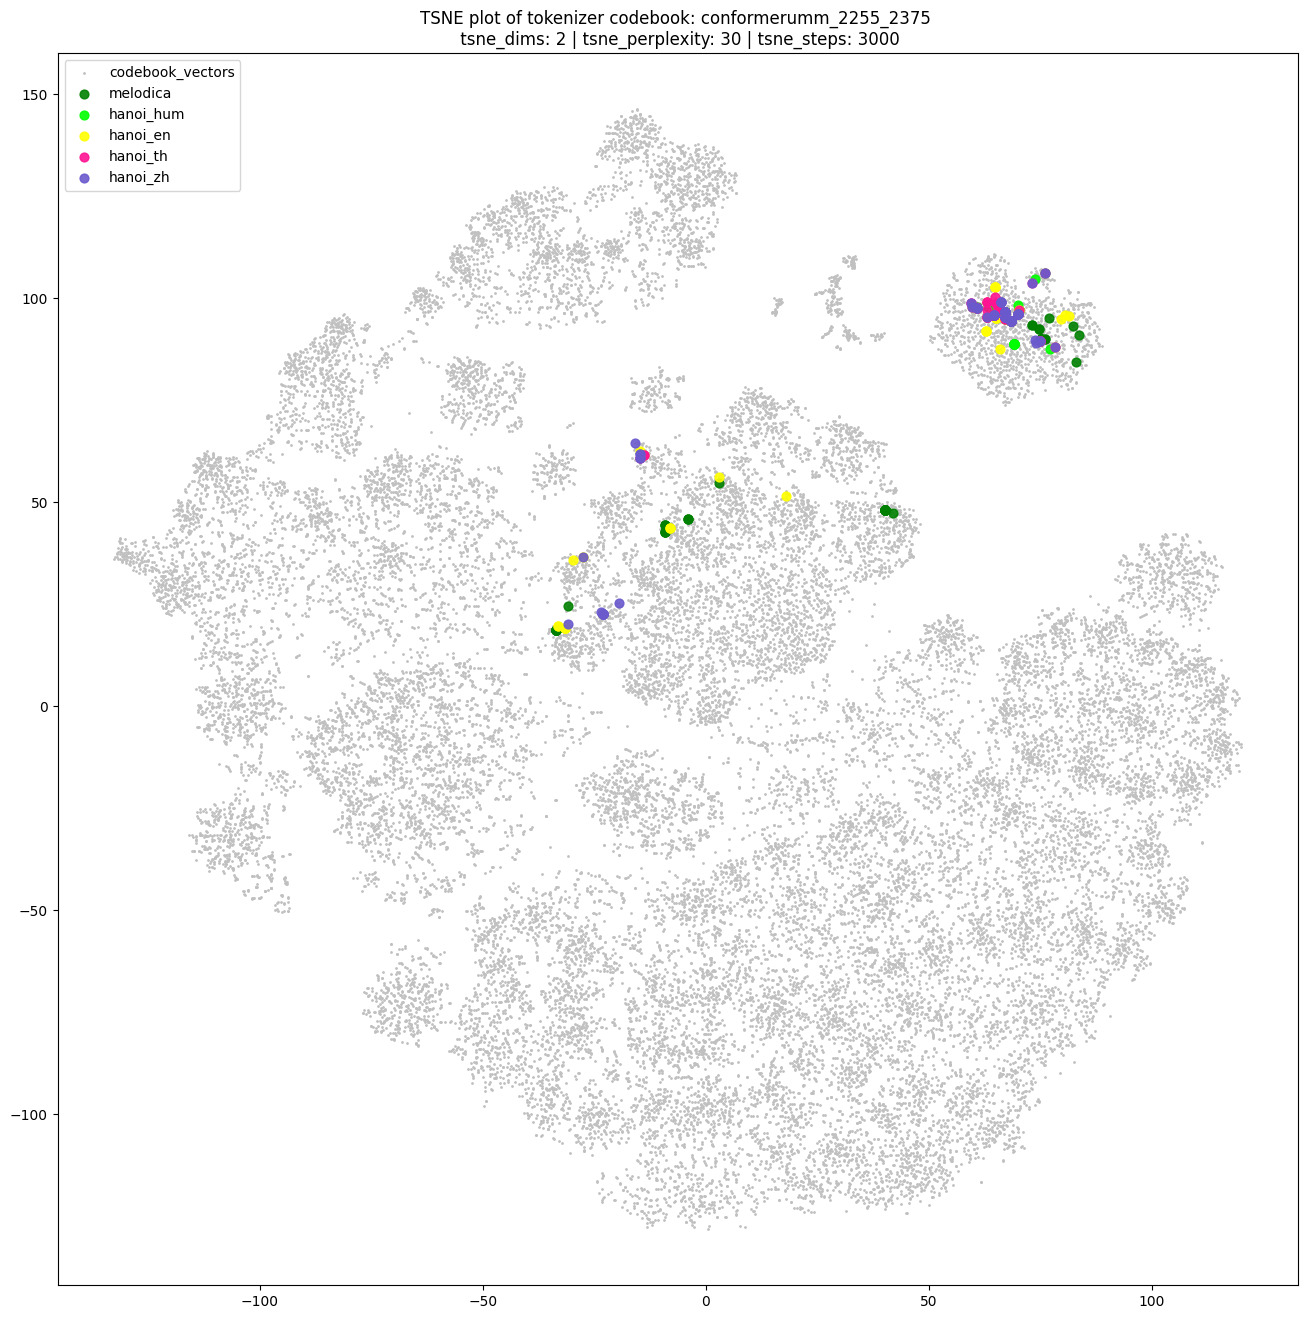

In [257]:
plt.figure(figsize=(16,16))
plt.title(f"TSNE plot of tokenizer codebook: {MODEL_KEY} \n tsne_dims: {TSNE_DIM} | tsne_perplexity: {TSNE_PERPLEXITY} | tsne_steps: {TSNE_STEPS}")
S_SIZE=40
ALPHA=0.9
plt.scatter(tsne_codebook[:,0], tsne_codebook[:,1], s=1, color='silver', label="codebook_vectors") # scatter plot of dimension 1 and dimension 2
plt.scatter(tsne_codebook[:,0][melodica_token_ids], tsne_codebook[:,1][melodica_token_ids], s=S_SIZE, alpha=ALPHA, color='green', label="melodica") # scatter plot of dimension 1 and dimension 2
plt.scatter(tsne_codebook[:,0][hum_token_ids], tsne_codebook[:,1][hum_token_ids], s=S_SIZE, alpha=ALPHA, color='lime', label="hanoi_hum") # scatter plot of dimension 1 and dimension 2
plt.scatter(tsne_codebook[:,0][en_token_ids], tsne_codebook[:,1][en_token_ids], s=S_SIZE, alpha=ALPHA, color='yellow', label="hanoi_en") # scatter plot of dimension 1 and dimension 2
plt.scatter(tsne_codebook[:,0][th_token_ids], tsne_codebook[:,1][th_token_ids], s=S_SIZE, alpha=ALPHA, color='deeppink', label="hanoi_th") # scatter plot of dimension 1 and dimension 2
plt.scatter(tsne_codebook[:,0][zh_token_ids], tsne_codebook[:,1][zh_token_ids], s=S_SIZE, alpha=ALPHA, color='slateblue', label="hanoi_zh") # scatter plot of dimension 1 and dimension 2
plt.legend(loc="upper left")

In [258]:
silence_audio_ids = np.concatenate([hum_token_ids[0:12], en_token_ids[0:10], th_token_ids[0:10], zh_token_ids[0:10]], axis=0)
print(silence_audio_ids)

[14549 16755 19775 19775 19775 19775 19775 16950 16950 16950 16950 16950
    81 14090 23451 16950 16950 16950 16950 16950 16950 16950    81 23451
 23451 23451 23451 23451 23451 23451 16950 16950    81 23451 23451 16950
 16950 16950 16950 16950 16950 16950]


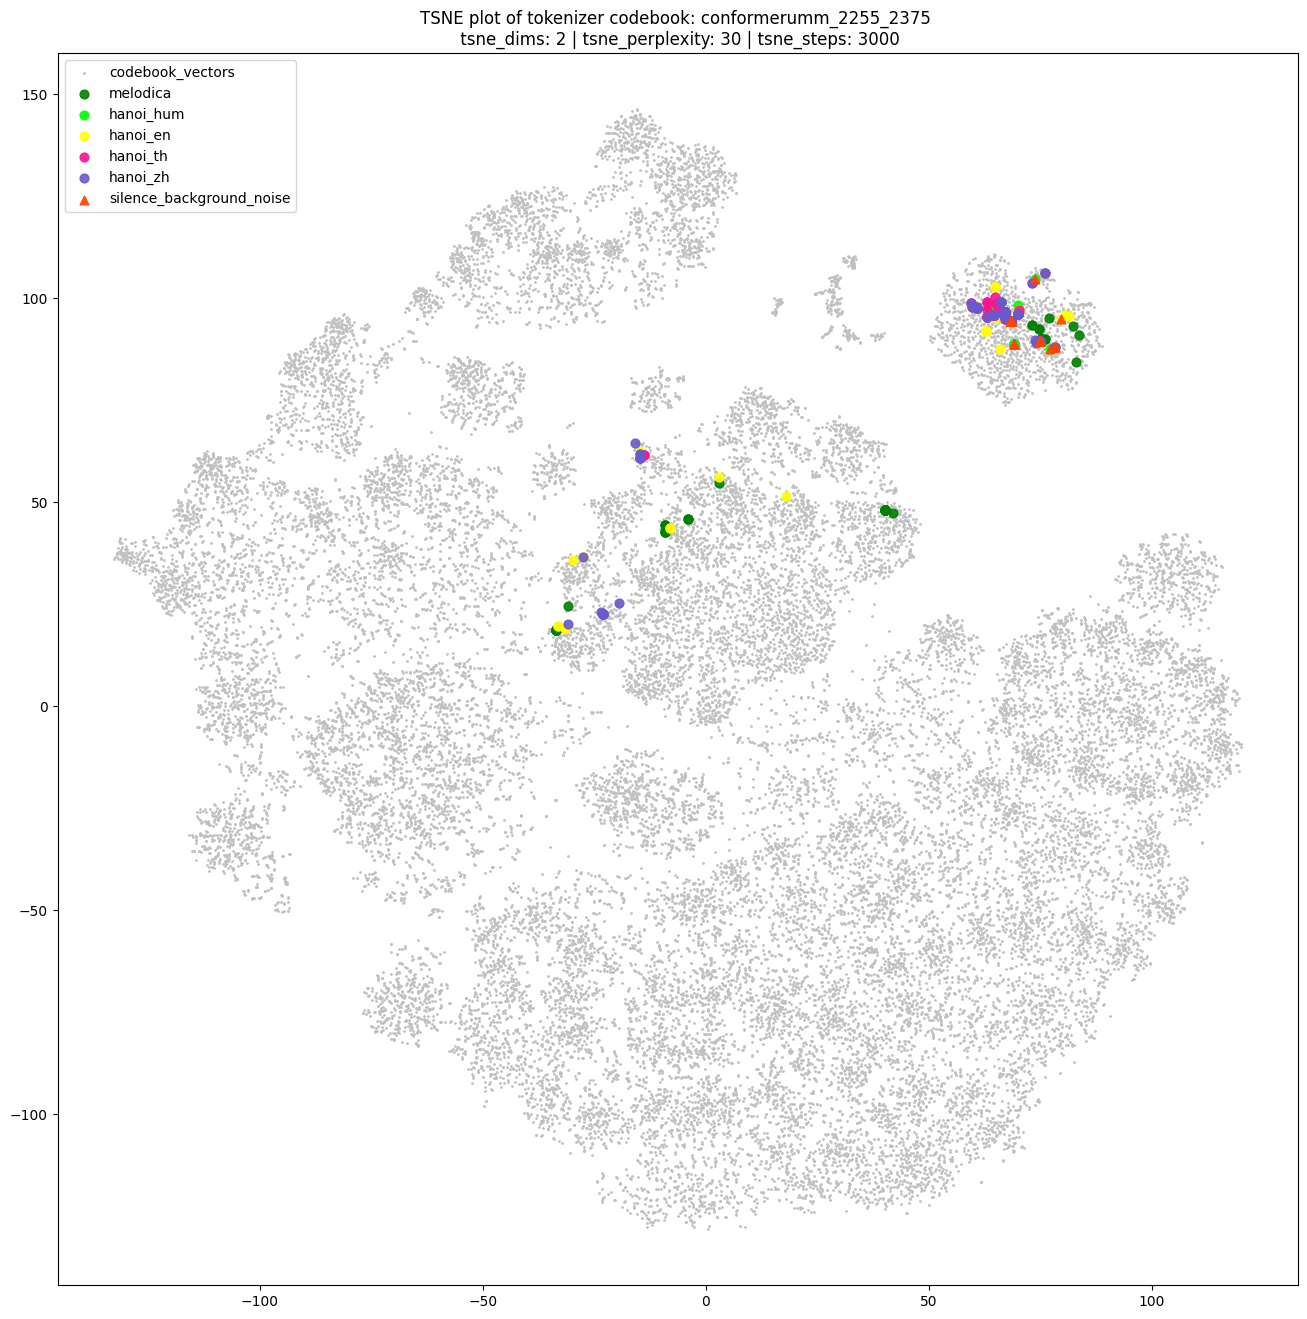

In [259]:
plt.figure(figsize=(16,16))
plt.title(f"TSNE plot of tokenizer codebook: {MODEL_KEY} \n tsne_dims: {TSNE_DIM} | tsne_perplexity: {TSNE_PERPLEXITY} | tsne_steps: {TSNE_STEPS}")
S_SIZE=40
ALPHA=0.9
plt.scatter(tsne_codebook[:,0], tsne_codebook[:,1], s=1, color='silver', label="codebook_vectors") # scatter plot of dimension 1 and dimension 2
plt.scatter(tsne_codebook[:,0][melodica_token_ids], tsne_codebook[:,1][melodica_token_ids], s=S_SIZE, alpha=ALPHA, color='green', label="melodica") # scatter plot of dimension 1 and dimension 2
plt.scatter(tsne_codebook[:,0][hum_token_ids], tsne_codebook[:,1][hum_token_ids], s=S_SIZE, alpha=ALPHA, color='lime', label="hanoi_hum") # scatter plot of dimension 1 and dimension 2
plt.scatter(tsne_codebook[:,0][en_token_ids], tsne_codebook[:,1][en_token_ids], s=S_SIZE, alpha=ALPHA, color='yellow', label="hanoi_en") # scatter plot of dimension 1 and dimension 2
plt.scatter(tsne_codebook[:,0][th_token_ids], tsne_codebook[:,1][th_token_ids], s=S_SIZE, alpha=ALPHA, color='deeppink', label="hanoi_th") # scatter plot of dimension 1 and dimension 2
plt.scatter(tsne_codebook[:,0][zh_token_ids], tsne_codebook[:,1][zh_token_ids], s=S_SIZE, alpha=ALPHA, color='slateblue', label="hanoi_zh") # scatter plot of dimension 1 and dimension 2

plt.scatter(tsne_codebook[:,0][silence_audio_ids], tsne_codebook[:,1][silence_audio_ids], marker='^', s=S_SIZE, alpha=ALPHA, color='orangered', label="silence_background_noise") # scatter plot of dimension 1 and dimension 2
plt.legend(loc="upper left")

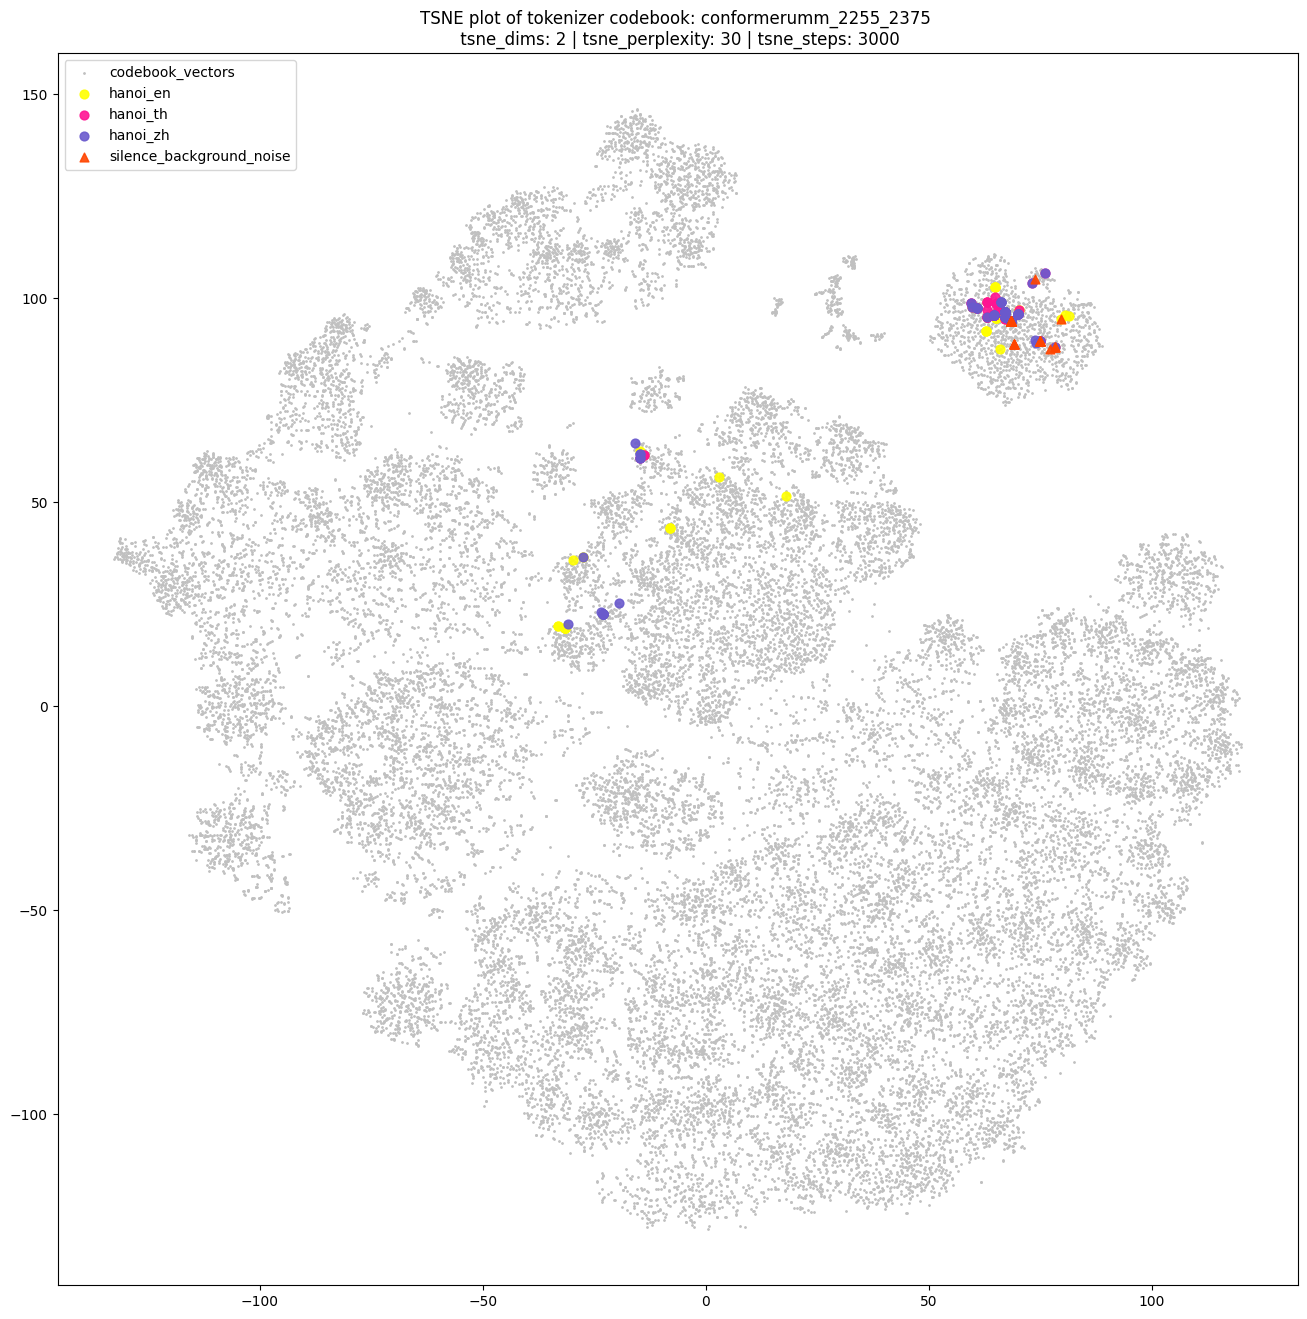

In [260]:
plt.figure(figsize=(16,16))
plt.title(f"TSNE plot of tokenizer codebook: {MODEL_KEY} \n tsne_dims: {TSNE_DIM} | tsne_perplexity: {TSNE_PERPLEXITY} | tsne_steps: {TSNE_STEPS}")
S_SIZE=40
ALPHA=0.9
plt.scatter(tsne_codebook[:,0], tsne_codebook[:,1], s=1, color='silver', label="codebook_vectors") # scatter plot of dimension 1 and dimension 2
# plt.scatter(tsne_codebook[:,0][melodica_token_ids], tsne_codebook[:,1][melodica_token_ids], s=S_SIZE, alpha=ALPHA, color='green', label="melodica") # scatter plot of dimension 1 and dimension 2
# plt.scatter(tsne_codebook[:,0][hum_token_ids], tsne_codebook[:,1][hum_token_ids], s=S_SIZE, alpha=ALPHA, color='lime', label="hanoi_hum") # scatter plot of dimension 1 and dimension 2
plt.scatter(tsne_codebook[:,0][en_token_ids], tsne_codebook[:,1][en_token_ids], s=S_SIZE, alpha=ALPHA, color='yellow', label="hanoi_en") # scatter plot of dimension 1 and dimension 2
plt.scatter(tsne_codebook[:,0][th_token_ids], tsne_codebook[:,1][th_token_ids], s=S_SIZE, alpha=ALPHA, color='deeppink', label="hanoi_th") # scatter plot of dimension 1 and dimension 2
plt.scatter(tsne_codebook[:,0][zh_token_ids], tsne_codebook[:,1][zh_token_ids], s=S_SIZE, alpha=ALPHA, color='slateblue', label="hanoi_zh") # scatter plot of dimension 1 and dimension 2

plt.scatter(tsne_codebook[:,0][silence_audio_ids], tsne_codebook[:,1][silence_audio_ids], marker='^', s=S_SIZE, alpha=ALPHA, color='orangered', label="silence_background_noise") # scatter plot of dimension 1 and dimension 2
plt.legend(loc="upper left")